In [1]:
import fastf1
from fastf1 import plotting
from matplotlib import pyplot as plt
import pandas as pd

plotting.setup_mpl()

### Tire degradation

In this section, I will analyze how different tire compounds (Soft, Medium, and Hard) lose performance over time.

In [3]:
race = fastf1.get_session(2021, 'Spain', 'R')
race.load()

req         WARNING 	DEFAULT CACHE ENABLED! (53.43 MB) C:\Users\PC\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Spanish Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track s

In [4]:
laps = race.laps

#data cleaning
clean_laps = laps.pick_quicklaps()
clean_laps = clean_laps.loc[clean_laps['TrackStatus'] == '1']

clean_laps = clean_laps.copy()
clean_laps['LapTimeSec'] = clean_laps['LapTime'].dt.total_seconds()

To perform an accurate tire analysis, I must filter out "noisy" data that doesn't reflect the true performance of the tires. I perform the following steps:
1. Removing Non-Racing Laps (pit-in and pit-out laps)
2. Removing laps where the driver made a mistake, spun, or encountered a local yellow flag.
3. Keeping laps where the `TrackStatus` is '1' (Green Track), ensuring no Safety Car or VSC periods interfere with the lap times.

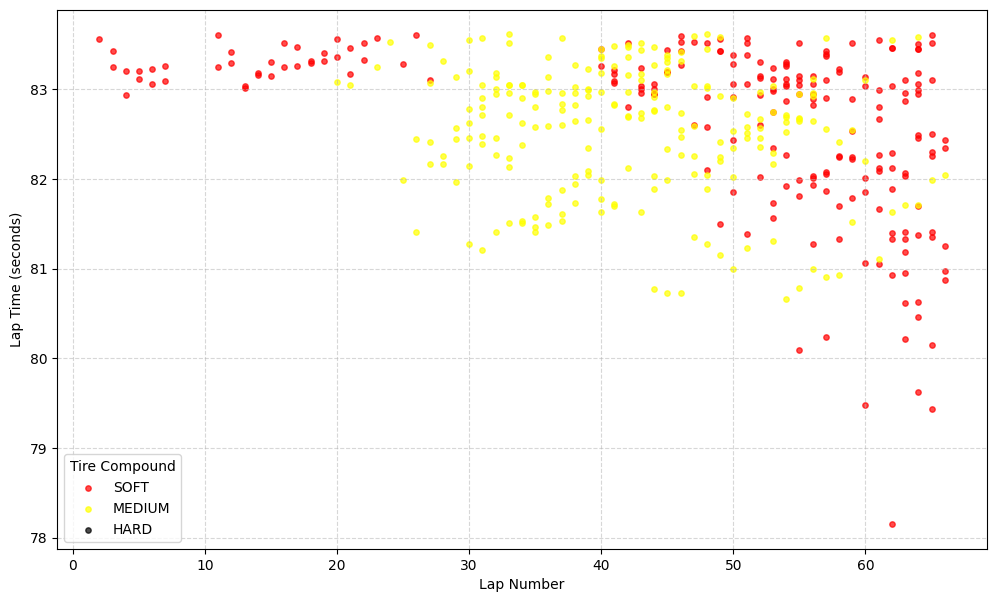

In [18]:
fig, ax = plt.subplots(figsize=(12, 7))

compound_colors = {'SOFT': 'red', 'MEDIUM': 'yellow', 'HARD': 'black'}

for compound in ['SOFT', 'MEDIUM', 'HARD']:
    df = clean_laps[clean_laps['Compound'] == compound]
    
    ax.scatter(df['LapNumber'], df['LapTimeSec'], 
               color=compound_colors[compound], 
               label=compound, 
               s=15, 
               alpha=0.7)

ax.set_xlabel('Lap Number')
ax.set_ylabel('Lap Time (seconds)')
ax.legend(title="Tire Compound")
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Conclusions

**Compound Performance Gap:** The Soft tires (Red) clearly provide the fastest initial lap times, sitting lower on the Y-axis. However, notice how the "cloud" of red dots ends early, showing their shorter lifespan.

**The Degradation Slope:** As the lap number increases, we see a general upward trend in lap times for the Mediums (Yellow). This is the "degradation" – the rubber wears out and the grip levels drop.

**Fuel Correction Effect:** A fascinating observation is the "dip" in times towards the end of the race (laps 60+). Even on older tires, the cars become faster because they are nearly empty of fuel, making the car significantly lighter.

**Strategy Outcome:** The data shows why the two-stop strategy was dominant; the pace drop-off on high-mileage tires (the upward climb of the dots) eventually makes a fresh set of tires much faster, even with the time lost in the pits.

### Top Speed vs. Tire Compound
In this section, I investigate whether the tire compound affects the absolute top speed of the car.

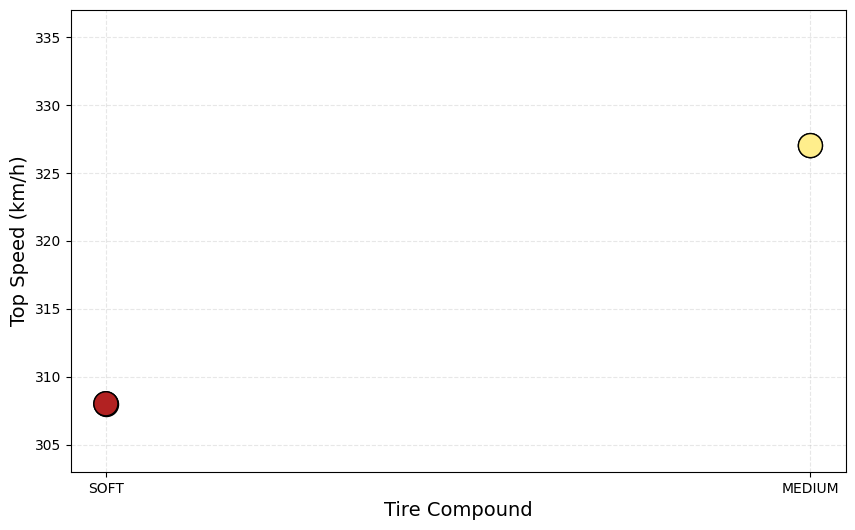

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

compounds = ['SOFT', 'MEDIUM', 'HARD']
compound_colours = {'SOFT': '#B22222', 'MEDIUM': '#FFEE8C', 'HARD': '#DBDBDC'}

valid_compounds = []
valid_colours = []
top_speeds = []

for compound in compounds:
    df_compound = clean_laps[clean_laps['Compound'] == compound]
    if len(df_compound) > 0:
        fastest_lap = df_compound.pick_fastest()
        telemetry = fastest_lap.get_telemetry()
        max_speed = telemetry['Speed'].max()
        top_speeds.append(max_speed)
        valid_compounds.append(compound)
        valid_colours.append(compound_colours[compound])


ax.scatter(valid_compounds, top_speeds, 
               color=valid_colours, 
               s=300, edgecolor='black', zorder=3)

ax.set_ylabel('Top Speed (km/h)', fontsize=14)
ax.set_xlabel('Tire Compound', fontsize=14)

if top_speeds:
    ax.set_ylim(min(top_speeds) - 5, max(top_speeds) + 10)
    
ax.grid(True, linestyle='--', alpha=0.3, zorder=0)

plt.show()
    

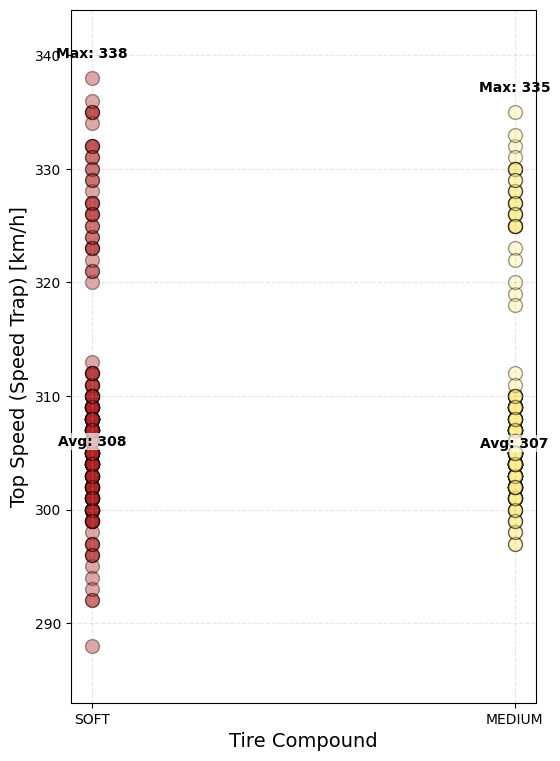

In [42]:
fig, ax = plt.subplots(figsize=(6, 9))

compounds = ['SOFT', 'MEDIUM', 'HARD']
compound_colours = {'SOFT': '#B22222', 'MEDIUM': '#FFEE8C', 'HARD': '#DBDBDC'}

all_speeds = []

for compound in compounds:
    df_compound = clean_laps[clean_laps['Compound'] == compound]
    
    speeds = df_compound['SpeedST'].dropna().tolist() # dropna() usuwa puste błędy
    
    if len(speeds) > 0:
        x_coords = [compound] * len(speeds)
        
        ax.scatter(x_coords, speeds, color=compound_colours[compound], 
                    s=100, alpha=0.4, edgecolor='black')
        
        avg_speed = sum(speeds) / len(speeds)
        max_speed = max(speeds)
        all_speeds.extend(speeds) 
        

        ax.text(compound, avg_speed - 1.5, f"Avg: {int(avg_speed)}", 
                ha='center', va='top', fontweight='bold', color='black',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
        
        ax.text(compound, max_speed + 1.5, f"Max: {int(max_speed)}", 
                ha='center', va='bottom', fontweight='bold', color='black')

ax.set_ylabel('Top Speed (Speed Trap) [km/h]', fontsize=14)
ax.set_xlabel('Tire Compound', fontsize=14)

if all_speeds:
    ax.set_ylim(min(all_speeds) - 5, max(all_speeds) + 6)
    
ax.grid(True, linestyle='--', alpha=0.3)

plt.show()